In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv('train_test_network.csv')

In [3]:
# Display no of raws and columns
df.shape

(211043, 44)

In [4]:
# Remove the column display limit
pd.set_option('display.max_columns', None)

# Display First 5 rows
df.head()

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_query,dns_qclass,dns_qtype,dns_rcode,dns_AA,dns_RD,dns_RA,dns_rejected,ssl_version,ssl_cipher,ssl_resumed,ssl_established,ssl_subject,ssl_issuer,http_trans_depth,http_method,http_uri,http_version,http_request_body_len,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,0,108,108064,31,3832,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,0,1,48,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor


In [5]:
# list all dataset columns
print("Full Dataset Columns", df.columns, sep='\n',
      end='\n\n')
print("Unique values in the 'category' column", 
      df['type'].unique(), sep='\n')
     


Full Dataset Columns
Index(['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service',
       'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes',
       'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query',
       'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA',
       'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed',
       'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth',
       'http_method', 'http_uri', 'http_version', 'http_request_body_len',
       'http_response_body_len', 'http_status_code', 'http_user_agent',
       'http_orig_mime_types', 'http_resp_mime_types', 'weird_name',
       'weird_addl', 'weird_notice', 'label', 'type'],
      dtype='object')

Unique values in the 'category' column
['backdoor' 'ddos' 'dos' 'injection' 'mitm' 'normal' 'password'
 'ransomware' 'scanning' 'xss']


In [ ]:
# Features for prototyping
trial_features = ['proto', 'duration', 'src_bytes', 'dst_bytes',
                  'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes',
                  'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype',
                  'dns_rcode', 'type']

subset_dataset =  df[trial_features]

In [7]:
# Remove the column display limit
pd.set_option('display.max_columns', None)

# Display First 5 rows
subset_dataset.head()

,proto,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_qclass,dns_qtype,dns_rcode,type
0,tcp,290.371539,101568,2592,OTH,0,108,108064,31,3832,0,0,0,backdoor
1,tcp,0.000102,0,0,REJ,0,1,52,1,40,0,0,0,backdoor
2,tcp,0.000148,0,0,REJ,0,1,52,1,40,0,0,0,backdoor
3,tcp,0.000113,0,0,REJ,0,1,48,1,40,0,0,0,backdoor
4,tcp,0.000130,0,0,REJ,0,1,52,1,40,0,0,0,backdoor


type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64


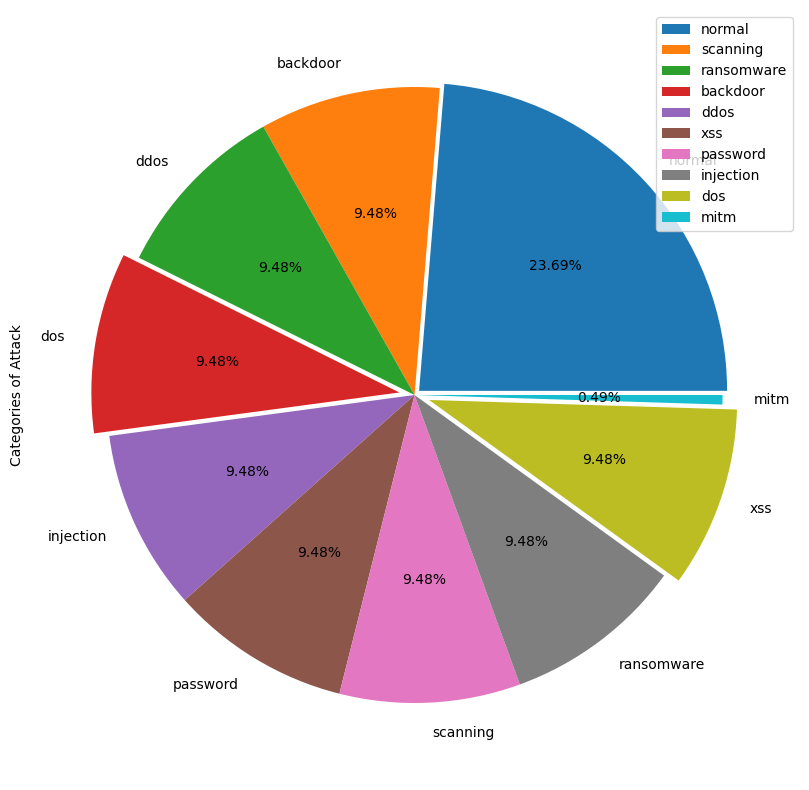

In [8]:
# check the number of unique values in the target variable
print(subset_dataset['type'].value_counts())
subset_dataset['type'].value_counts().plot(kind = 'pie',
                                           explode = [0.02, 0, 0, 0.05, 0, 0,
                                                      0, 0, 0.05, 0],
                                           figsize = (10, 10),
                                           autopct = '%1.2f%%',
                                           shadow = False)
plt.ylabel("Categories of Attack")
plt.legend(['normal', 'scanning', 'ransomware', 'backdoor', 'ddos', 'xss',
            'password', 'injection', 'dos', 'mitm'])
plt.show()

In [9]:
# check the data type of dataframe columns
subset_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   proto         211043 non-null  object 
 1   duration      211043 non-null  float64
 2   src_bytes     211043 non-null  int64  
 3   dst_bytes     211043 non-null  int64  
 4   conn_state    211043 non-null  object 
 5   missed_bytes  211043 non-null  int64  
 6   src_pkts      211043 non-null  int64  
 7   src_ip_bytes  211043 non-null  int64  
 8   dst_pkts      211043 non-null  int64  
 9   dst_ip_bytes  211043 non-null  int64  
 10  dns_qclass    211043 non-null  int64  
 11  dns_qtype     211043 non-null  int64  
 12  dns_rcode     211043 non-null  int64  
 13  type          211043 non-null  object 
dtypes: float64(1), int64(10), object(3)
memory usage: 22.5+ MB


In [10]:
# check for missing values
# subset_dataset[subset_dataset.isnull().any(axis=1)]
subset_dataset.isnull().any(axis=1)

0         False
1         False
2         False
3         False
4         False
          ...  
211038    False
211039    False
211040    False
211041    False
211042    False
Length: 211043, dtype: bool

In [11]:
# Split Data into Features and Target variables
X = subset_dataset.iloc[:, :-1].values
y = subset_dataset.type

In [12]:
print(X)

[['tcp' 290.371539 101568 ... 0 0 0]
 ['tcp' 0.000102 0 ... 0 0 0]
 ['tcp' 0.000148 0 ... 0 0 0]
 ...
 ['tcp' 65.766512 3922 ... 0 0 0]
 ['tcp' 65.75394 2401 ... 0 0 0]
 ['tcp' 65.771855 3181 ... 0 0 0]]


In [13]:
print(y)

0         backdoor
1         backdoor
2         backdoor
3         backdoor
4         backdoor
            ...   
211038         xss
211039         xss
211040         xss
211041         xss
211042         xss
Name: type, Length: 211043, dtype: object


In [14]:
X.shape

(211043, 13)

In [15]:
# Handling Categorical Data
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(transformers=[('enconder', OneHotEncoder(), [0, 4])], remainder='passthrough')
encoded_X = np.array(ct.fit_transform(X))
encoded_X[:,:12]

array([[0.0, 1.0, 0.0, ..., 0.0, 0.0, 0.0],
       [0.0, 1.0, 0.0, ..., 0.0, 0.0, 0.0],
       [0.0, 1.0, 0.0, ..., 0.0, 0.0, 0.0],
       ...,
       [0.0, 1.0, 0.0, ..., 0.0, 0.0, 0.0],
       [0.0, 1.0, 0.0, ..., 0.0, 0.0, 0.0],
       [0.0, 1.0, 0.0, ..., 0.0, 0.0, 0.0]],
      shape=(211043, 12), dtype=object)

In [16]:
encoded_X.shape

(211043, 27)

In [17]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
encoded_y = label_encoder.fit_transform(y)
label_encoder_name_mapping = dict(zip(label_encoder.classes_,
                                     label_encoder.transform(label_encoder.classes_)))
print("Mapping of Label Encoded Classes", label_encoder_name_mapping, sep="\n")

Mapping of Label Encoded Classes
{'backdoor': np.int64(0), 'ddos': np.int64(1), 'dos': np.int64(2), 'injection': np.int64(3), 'mitm': np.int64(4), 'normal': np.int64(5), 'password': np.int64(6), 'ransomware': np.int64(7), 'scanning': np.int64(8), 'xss': np.int64(9)}


In [18]:
# Splitting Dataset into Training and Validation Set
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(encoded_X, encoded_y, test_size=0.25,
                                                  random_state=0, 
                                                  stratify=encoded_y)

print('X Training set', X_train, sep='\n')
print('X Validation set', X_val, sep='\n')
print('y Training set', y_val, sep='\n')
print('y Validation set', y_val, sep='\n')

X Training set
[[0.0 1.0 0.0 ... 0 0 0]
 [0.0 1.0 0.0 ... 0 0 0]
 [0.0 1.0 0.0 ... 0 0 0]
 ...
 [0.0 0.0 1.0 ... 1 1 0]
 [0.0 1.0 0.0 ... 0 0 0]
 [0.0 0.0 1.0 ... 1 1 0]]
X Validation set
[[0.0 0.0 1.0 ... 1 28 0]
 [0.0 1.0 0.0 ... 0 0 0]
 [0.0 1.0 0.0 ... 0 0 0]
 ...
 [0.0 1.0 0.0 ... 0 0 0]
 [0.0 1.0 0.0 ... 0 0 0]
 [0.0 1.0 0.0 ... 0 0 0]]
y Training set
[5 7 0 ... 5 6 8]
y Validation set
[5 7 0 ... 5 6 8]


In [19]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_val = scaler.transform(X_val)
print(scaled_X_train)
print(scaled_X_val)
print(len(scaled_X_train))
print(len(scaled_X_val))

[[-0.03618708  0.50073631 -0.49869265 ... -0.08443775 -0.15183337
  -0.20714427]
 [-0.03618708  0.50073631 -0.49869265 ... -0.08443775 -0.15183337
  -0.20714427]
 [-0.03618708  0.50073631 -0.49869265 ... -0.08443775 -0.15183337
  -0.20714427]
 ...
 [-0.03618708 -1.99705907  2.0052431  ... -0.08407352 -0.10996412
  -0.20714427]
 [-0.03618708  0.50073631 -0.49869265 ... -0.08443775 -0.15183337
  -0.20714427]
 [-0.03618708 -1.99705907  2.0052431  ... -0.08407352 -0.10996412
  -0.20714427]]
[[-0.03618708 -1.99705907  2.0052431  ... -0.08407352  1.02050569
  -0.20714427]
 [-0.03618708  0.50073631 -0.49869265 ... -0.08443775 -0.15183337
  -0.20714427]
 [-0.03618708  0.50073631 -0.49869265 ... -0.08443775 -0.15183337
  -0.20714427]
 ...
 [-0.03618708  0.50073631 -0.49869265 ... -0.08443775 -0.15183337
  -0.20714427]
 [-0.03618708  0.50073631 -0.49869265 ... -0.08443775 -0.15183337
  -0.20714427]
 [-0.03618708  0.50073631 -0.49869265 ... -0.08443775 -0.15183337
  -0.20714427]]
158282
52761


In [20]:
# Train Model
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
from sklearn.metrics import precision_score, f1_score, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

def evaluate_model(y_val, y_pred):
  """Function to evaluate model and return the metric of the model
  
  It returns a dictionary with the classification metrics.
  """
  accuracy = accuracy_score(y_val, y_pred)
  precision = precision_score(y_val, y_pred, average='macro')
  recall = recall_score(y_val, y_pred, average='macro')
  f1 = f1_score(y_val, y_pred, average='macro')
  result = {"accuracy_score": accuracy,
            "precision_score": precision,
            "recall_score": recall,
            "f1_score": f1}
  return result

def plot_confusion_matrix(y_val, y_pred, label):
  '''function to plot confusion matrix

  Args
  y_val: array. The validation set of the target variable.
  y_pred: array. Model's prediction.
  label: list. A list containing all the classes in the target variable

  Returns
  It returns a plot of the confusion matrix
  '''
  cm = confusion_matrix(y_val, y_pred)
  fig, ax = plt.subplots(figsize=(10,10))
  ConfusionMatrixDisplay(cm, display_labels=label).plot(ax=ax, values_format='', xticks_rotation='vertical')

# class labels
label = ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']

{'accuracy_score': 0.7198309357290423, 'precision_score': 0.718110187244052, 'recall_score': 0.6484471264367816, 'f1_score': 0.6305655014871203}
              precision    recall  f1-score   support

           0       0.47      0.99      0.63      5000
           1       0.77      0.91      0.83      5000
           2       0.90      0.16      0.27      5000
           3       0.73      0.73      0.73      5000
           4       0.43      0.06      0.10       261
           5       0.86      0.78      0.82     12500
           6       0.67      0.51      0.58      5000
           7       0.70      0.84      0.76      5000
           8       0.79      0.77      0.78      5000
           9       0.88      0.73      0.80      5000

    accuracy                           0.72     52761
   macro avg       0.72      0.65      0.63     52761
weighted avg       0.76      0.72      0.70     52761



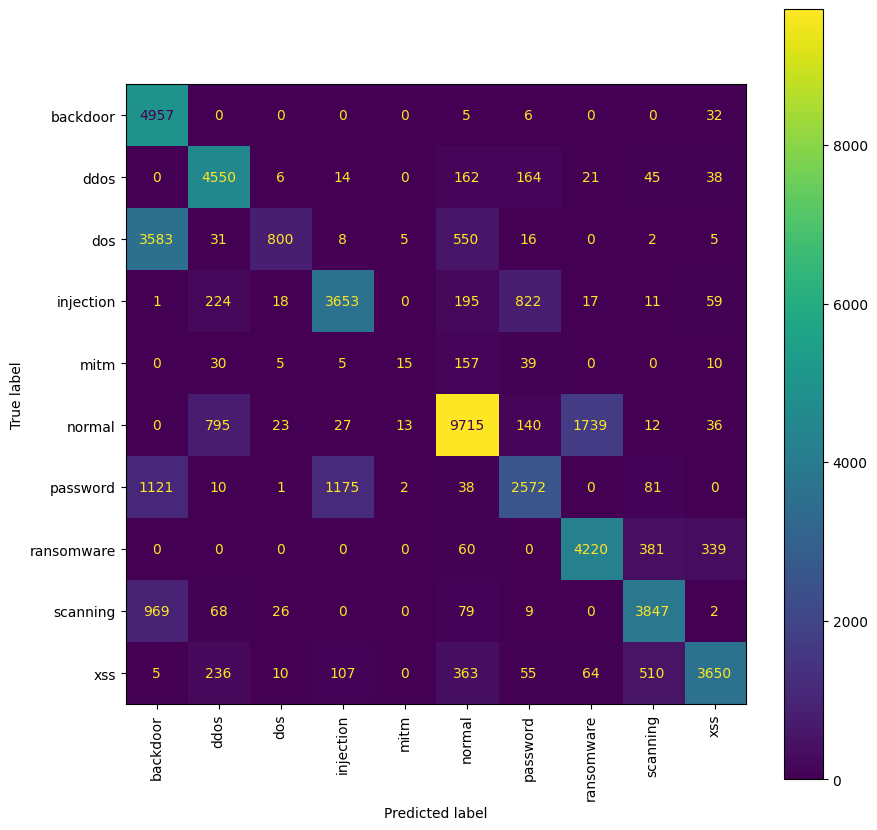

In [21]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

logistic_regression_model = LogisticRegression(max_iter=3000)
logistic_regression_model.fit(scaled_X_train, y_train)
logistic_regression_y_pred = logistic_regression_model.predict(scaled_X_val)
print(evaluate_model(y_val, logistic_regression_y_pred))
plot_confusion_matrix(y_val, logistic_regression_y_pred, label)
print(classification_report(y_val, logistic_regression_y_pred))

{'accuracy_score': 0.9713045620818408, 'precision_score': 0.938342272726506, 'recall_score': 0.9467815019157086, 'f1_score': 0.941827749256545}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5000
           1       0.98      0.97      0.97      5000
           2       0.99      0.98      0.98      5000
           3       0.96      0.96      0.96      5000
           4       0.64      0.74      0.69       261
           5       0.99      0.99      0.99     12500
           6       0.99      0.97      0.98      5000
           7       0.98      0.91      0.94      5000
           8       0.99      0.99      0.99      5000
           9       0.87      0.96      0.91      5000

    accuracy                           0.97     52761
   macro avg       0.94      0.95      0.94     52761
weighted avg       0.97      0.97      0.97     52761



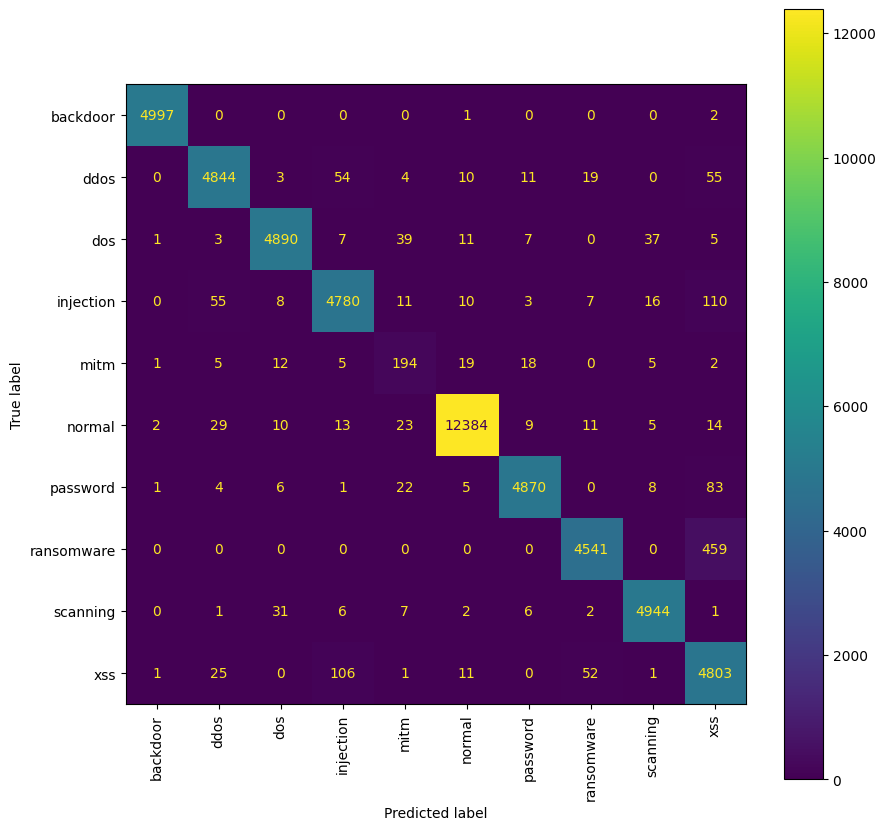

In [22]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn_model.fit(scaled_X_train, y_train)
knn_y_pred = knn_model.predict(scaled_X_val)

print(evaluate_model(y_val, knn_y_pred))
plot_confusion_matrix(y_val, knn_y_pred, label)
print(classification_report(y_val, knn_y_pred))

In [ ]:
# SVM - Takes long time
from sklearn import svm
svm_model = svm.SVC(kernel='rbf')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(scaled_X_val)

print(evaluate_model(y_val, y_pred_svm))
print(classification_report(y_val, y_pred_svm))
plot_confusion_matrix(y_val, y_pred_svm, label)

/home/maheshr/RHD/Research/py_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/maheshr/RHD/Research/py_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/maheshr/RHD/Research/py_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

{'accuracy_score': 0.31619946551430034, 'precision_score': 0.09633588641504445, 'recall_score': 0.19435483524904215, 'f1_score': 0.117586305724288}
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      5000
           1       0.00      0.00      0.00      5000
           2       0.37      0.83      0.51      5000
           3       0.00      0.00      0.00      5000
           4       0.17      0.08      0.11       261
           5       0.32      0.98      0.48     12500
           6       0.00      0.00      0.00      5000
           7       0.10      0.06      0.08      5000
           8       0.00      0.00      0.00      5000
           9       0.00      0.00      0.00      5000

    accuracy                           0.32     52761
   macro avg       0.10      0.19      0.12     52761
weighted avg       0.12      0.32      0.17     52761



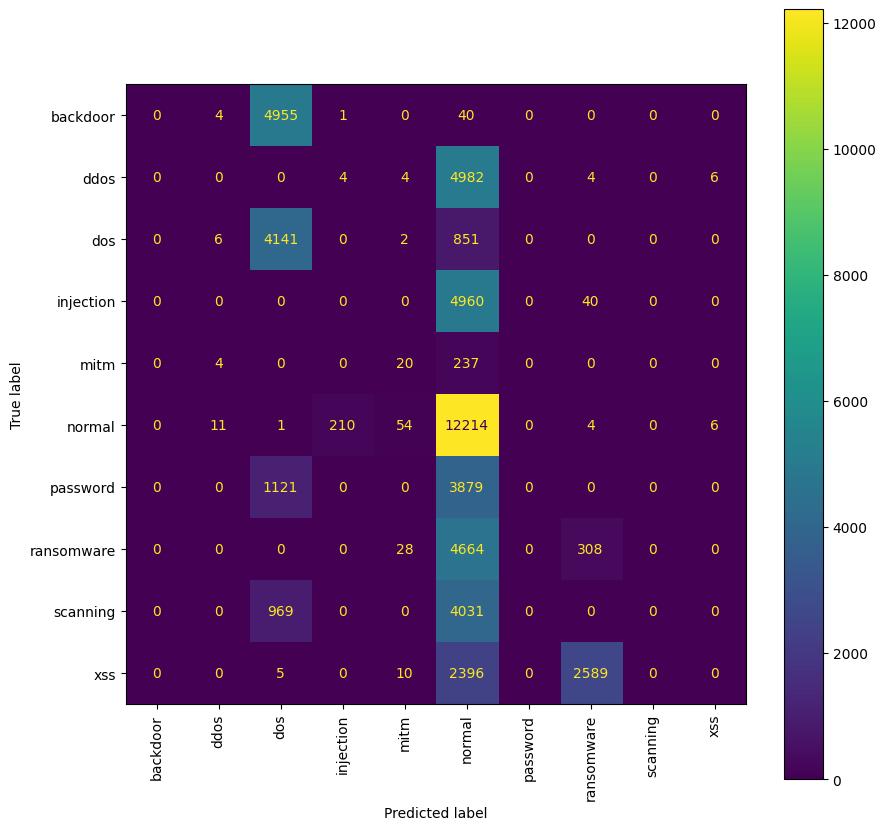

In [23]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(criterion="entropy",
                                             min_samples_split=40,
                                             random_state=0)
decision_tree_model.fit(X_train, y_train)
decision_tree_y_pred = decision_tree_model.predict(scaled_X_val)

print(evaluate_model(y_val, decision_tree_y_pred))
print(classification_report(y_val, decision_tree_y_pred))
plot_confusion_matrix(y_val, decision_tree_y_pred, label)

/home/maheshr/RHD/Research/py_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/maheshr/RHD/Research/py_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/maheshr/RHD/Research/py_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

{'accuracy_score': 0.19859365819449973, 'precision_score': 0.13701559162591614, 'recall_score': 0.09178056704980844, 'f1_score': 0.05077470105996336}
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      5000
           1       0.00      0.00      0.00      5000
           2       0.03      0.05      0.04      5000
           3       0.00      0.00      0.00      5000
           4       1.00      0.02      0.03       261
           5       0.24      0.79      0.36     12500
           6       0.00      0.00      0.00      5000
           7       0.10      0.06      0.08      5000
           8       0.00      0.00      0.00      5000
           9       0.00      0.00      0.00      5000

    accuracy                           0.20     52761
   macro avg       0.14      0.09      0.05     52761
weighted avg       0.07      0.20      0.10     52761



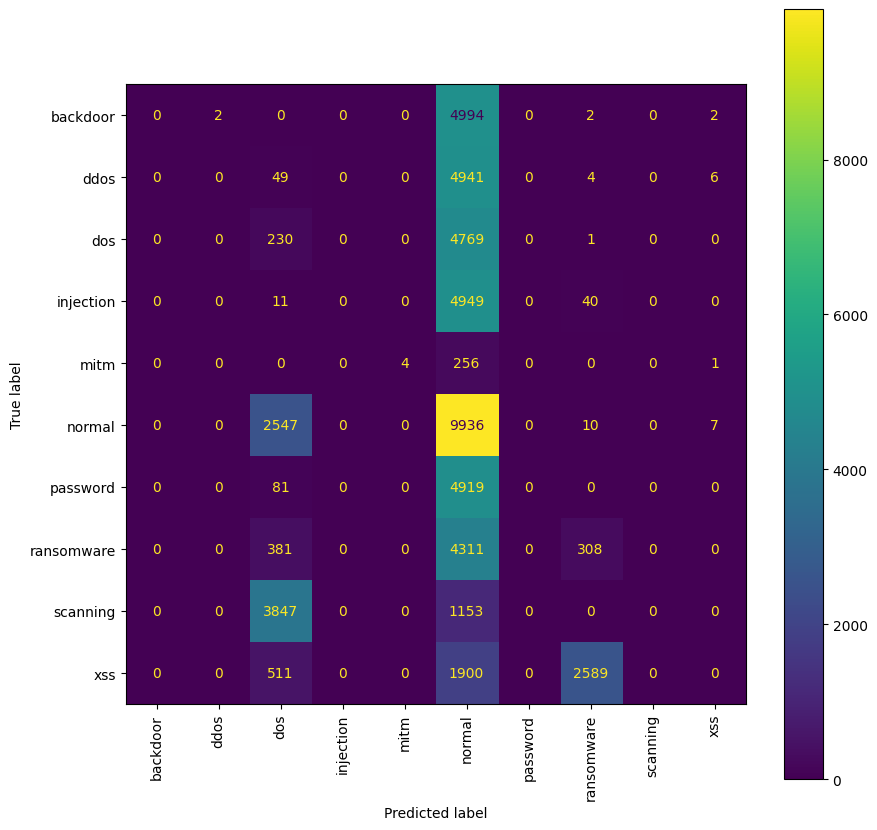

In [24]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(n_estimators=100,
                                             criterion="entropy",
                                             min_samples_split=30,
                                             random_state=0)
random_forest_model.fit(X_train, y_train)
random_forest_y_pred = random_forest_model.predict(scaled_X_val)

print(evaluate_model(y_val, random_forest_y_pred))
print(classification_report(y_val, random_forest_y_pred))
plot_confusion_matrix(y_val, random_forest_y_pred, label)

{'accuracy_score': 0.35152859119425334, 'precision_score': 0.35119412168542097, 'recall_score': 0.36242649808429117, 'f1_score': 0.27225725173015336}
              precision    recall  f1-score   support

           0       0.44      0.99      0.61      5000
           1       0.61      0.06      0.11      5000
           2       0.14      0.09      0.11      5000
           3       0.13      0.07      0.09      5000
           4       0.07      0.26      0.11       261
           5       0.98      0.22      0.36     12500
           6       0.43      0.75      0.55      5000
           7       0.37      0.98      0.53      5000
           8       0.02      0.02      0.02      5000
           9       0.32      0.17      0.22      5000

    accuracy                           0.35     52761
   macro avg       0.35      0.36      0.27     52761
weighted avg       0.47      0.35      0.30     52761



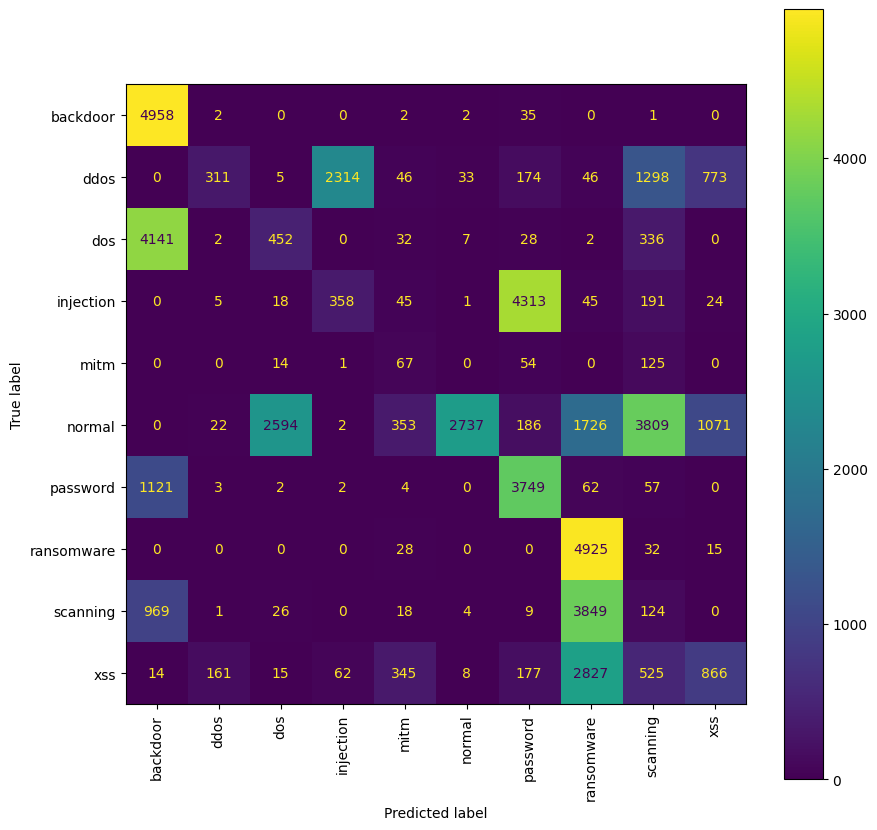

In [25]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(scaled_X_train, y_train)
y_pred_nb = naive_bayes_model.predict(scaled_X_val)

print(evaluate_model(y_val, y_pred_nb))
print(classification_report(y_val, y_pred_nb))
plot_confusion_matrix(y_val, y_pred_nb, label)

{'accuracy_score': 0.9772938344610602, 'precision_score': 0.9487101635345712, 'recall_score': 0.9516312183908046, 'f1_score': 0.9499655797273837}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5000
           1       0.99      0.97      0.98      5000
           2       0.99      0.98      0.98      5000
           3       0.98      0.96      0.97      5000
           4       0.70      0.74      0.72       261
           5       0.99      1.00      0.99     12500
           6       0.99      0.98      0.98      5000
           7       0.92      0.98      0.95      5000
           8       0.99      0.99      0.99      5000
           9       0.95      0.92      0.94      5000

    accuracy                           0.98     52761
   macro avg       0.95      0.95      0.95     52761
weighted avg       0.98      0.98      0.98     52761



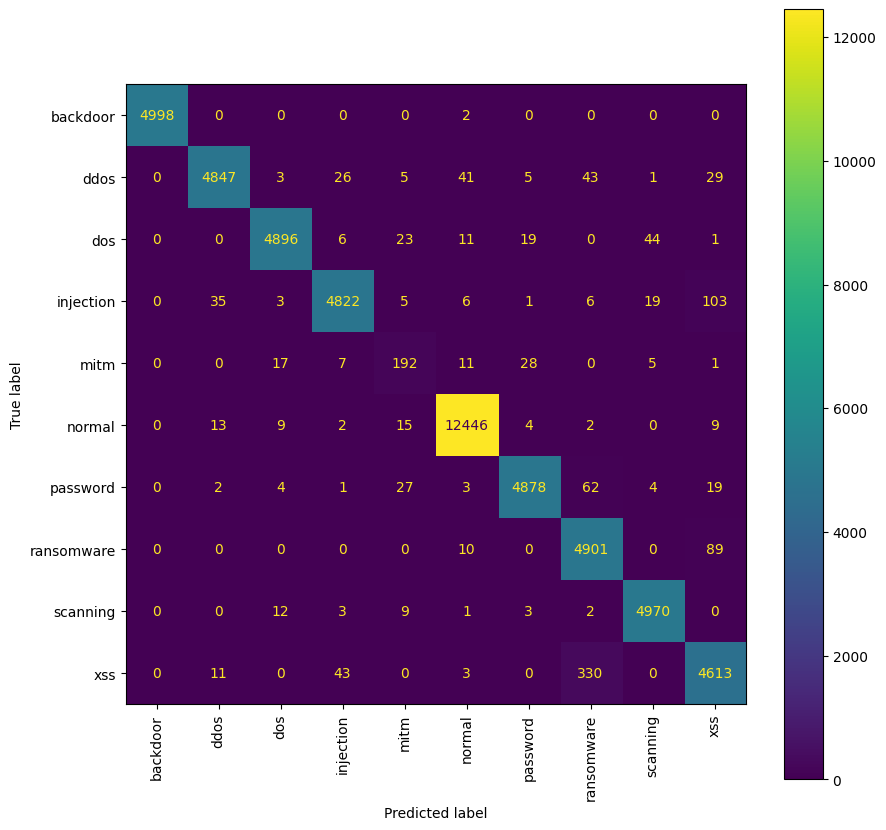

In [26]:
# XGBoost
from xgboost import XGBClassifier

xgboost_model = XGBClassifier()
xgboost_model.fit(scaled_X_train, y_train)
y_pred_xgb = xgboost_model.predict(scaled_X_val)

print(evaluate_model(y_val, y_pred_xgb))
print(classification_report(y_val, y_pred_xgb))
plot_confusion_matrix(y_val, y_pred_xgb, label)

Artificial Neural Network

In [28]:
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

# Encode string labels → integers
le = LabelEncoder()
y_train_int = le.fit_transform(y_train)
y_val_int = le.transform(y_val)

# Convert integers → one-hot vectors
encoded_y_train = to_categorical(y_train_int)
encoded_y_val = to_categorical(y_val_int)

In [29]:
import tensorflow as tf
print(tf.__version__)

ann_model = tf.keras.models.Sequential()
ann_model.add(tf.keras.layers.Dense(units=12, activation='relu'))
ann_model.add(tf.keras.layers.Dense(units=8, activation='relu'))
ann_model.add(tf.keras.layers.Dense(units=8, activation='relu'))
ann_model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

ann_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
history = ann_model.fit(scaled_X_train, encoded_y_train, validation_split=0.25, batch_size=32, epochs=100)

2.21.0
Epoch 1/100


E0000 00:00:1781426262.719670   30348 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


3710/3710 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.6386 - loss: 0.9484 - precision: 0.8021 - recall: 0.4520 - val_accuracy: 0.6719 - val_loss: 0.8267 - val_precision: 0.7583 - val_recall: 0.5686
Epoch 2/100
3710/3710 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6755 - loss: 0.8003 - precision: 0.7974 - recall: 0.5277 - val_accuracy: 0.6961 - val_loss: 0.7927 - val_precision: 0.8401 - val_recall: 0.4925
Epoch 3/100
3710/3710 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6898 - loss: 0.7707 - precision: 0.8045 - recall: 0.5562 - val_accuracy: 0.6736 - val_loss: 0.7643 - val_precision: 0.7995 - val_recall: 0.5650
Epoch 4/100
3710/3710 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6997 - loss: 0.7501 - precision: 0.8071 - recall: 0.5796 - val_accuracy: 0.7061 - val_loss: 0.7376 - val_precision: 0.8101 - val_recall: 0.5756
Epoch 5/100
3710/3710 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7041 - loss: 0.7354 - precision: 0.8103 - recall: 0.5892 - val_accuracy: 0.7168 - val_loss:

In [30]:
ann_y_pred = ann_model.predict(scaled_X_val)
ann_y_pred = (ann_y_pred > 0.5)
ann_y_pred

1649/1649 ━━━━━━━━━━━━━━━━━━━━ 1s 440us/step


array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False,  True],
       [ True, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False,  True, False]], shape=(52761, 10))

In [31]:
# Check the validation accuracy
_, accuracy, precision, recall = ann_model.evaluate(scaled_X_val, encoded_y_val)
print('Accuracy: %.2f' % (accuracy*100))

1649/1649 ━━━━━━━━━━━━━━━━━━━━ 1s 706us/step - accuracy: 0.8128 - loss: 0.5194 - precision: 0.8356 - recall: 0.8004
Accuracy: 81.28


Text(0.5, 0, 'epoch')

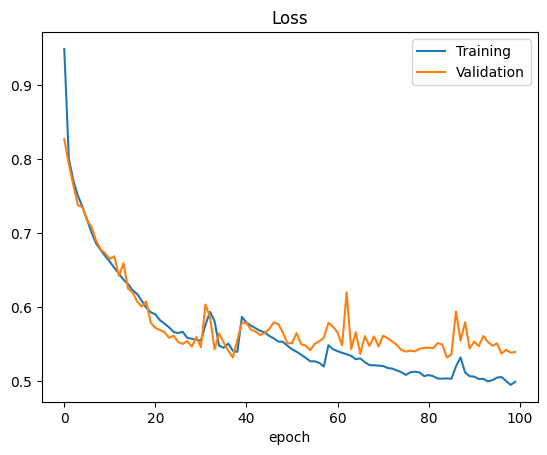

In [32]:
# Plot graph between training and validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Training', 'Validation'])
plt.title('Loss')
plt.xlabel('epoch')

Text(0.5, 0, 'epoch')

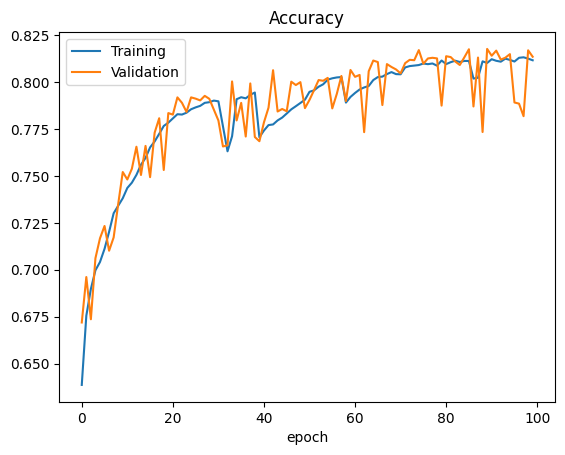

In [33]:
# Plot graph between training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Training', 'Validation'])
plt.title('Accuracy')
plt.xlabel('epoch')

Text(0.5, 0, 'epoch')

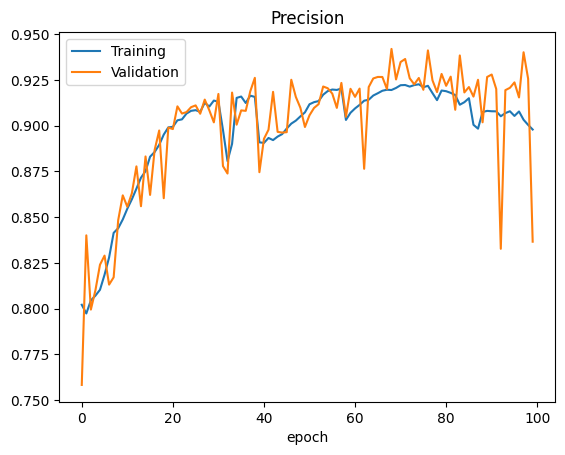

In [34]:
# Plot graph between training and validation precision
plt.plot(history.history['precision'])
plt.plot(history.history['val_precision'])
plt.legend(['Training', 'Validation'])
plt.title('Precision')
plt.xlabel('epoch')

Text(0.5, 0, 'epoch')

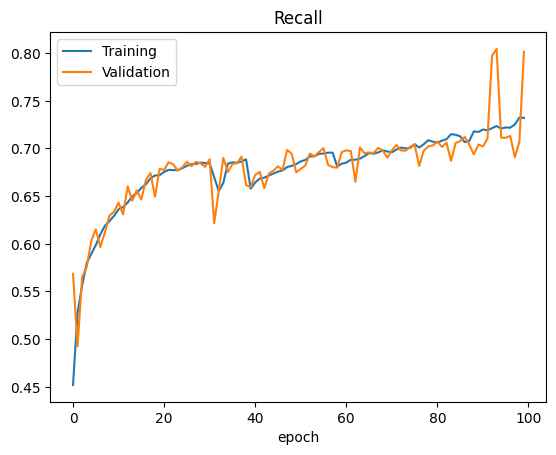

In [35]:
# Plot graph between training and validation recall
plt.plot(history.history['recall'])
plt.plot(history.history['val_recall'])
plt.legend(['Training', 'Validation'])
plt.title('Recall')
plt.xlabel('epoch')

{'accuracy_score': 0.8004776255188492, 'precision_score': 0.8783552502356912, 'recall_score': 0.7106431417624521, 'f1_score': 0.7035390425612368}
              precision    recall  f1-score   support

           0       0.39      1.00      0.56      5000
           1       0.81      0.93      0.87      5000
           2       0.94      0.18      0.30      5000
           3       0.95      0.89      0.92      5000
           4       1.00      0.00      0.01       261
           5       0.99      0.90      0.94     12500
           6       0.96      0.75      0.84      5000
           7       0.98      0.89      0.93      5000
           8       0.83      0.77      0.80      5000
           9       0.92      0.80      0.86      5000

    accuracy                           0.80     52761
   macro avg       0.88      0.71      0.70     52761
weighted avg       0.88      0.80      0.80     52761



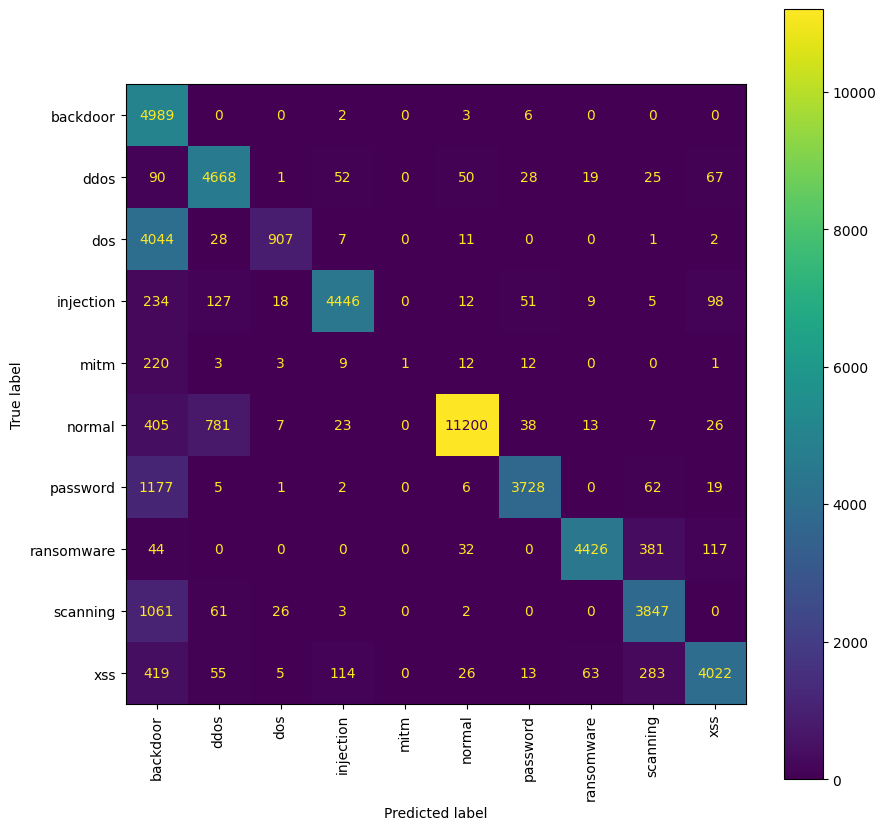

In [36]:
print(evaluate_model(encoded_y_val.argmax(axis=1), ann_y_pred.argmax(axis=1)))
print(classification_report(encoded_y_val.argmax(axis=1), ann_y_pred.argmax(axis=1)))
plot_confusion_matrix(encoded_y_val.argmax(axis=1), ann_y_pred.argmax(axis=1), label)

{'accuracy_score': 0.9768199996209321, 'precision_score': 0.9404870561338183, 'recall_score': 0.9632948965517241, 'f1_score': 0.9495441473207753}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5000
           1       0.98      0.97      0.98      5000
           2       1.00      0.98      0.99      5000
           3       0.98      0.96      0.97      5000
           4       0.61      0.86      0.71       261
           5       0.99      0.99      0.99     12500
           6       0.99      0.97      0.98      5000
           7       0.92      0.98      0.95      5000
           8       0.99      0.99      0.99      5000
           9       0.95      0.92      0.93      5000

    accuracy                           0.98     52761
   macro avg       0.94      0.96      0.95     52761
weighted avg       0.98      0.98      0.98     52761



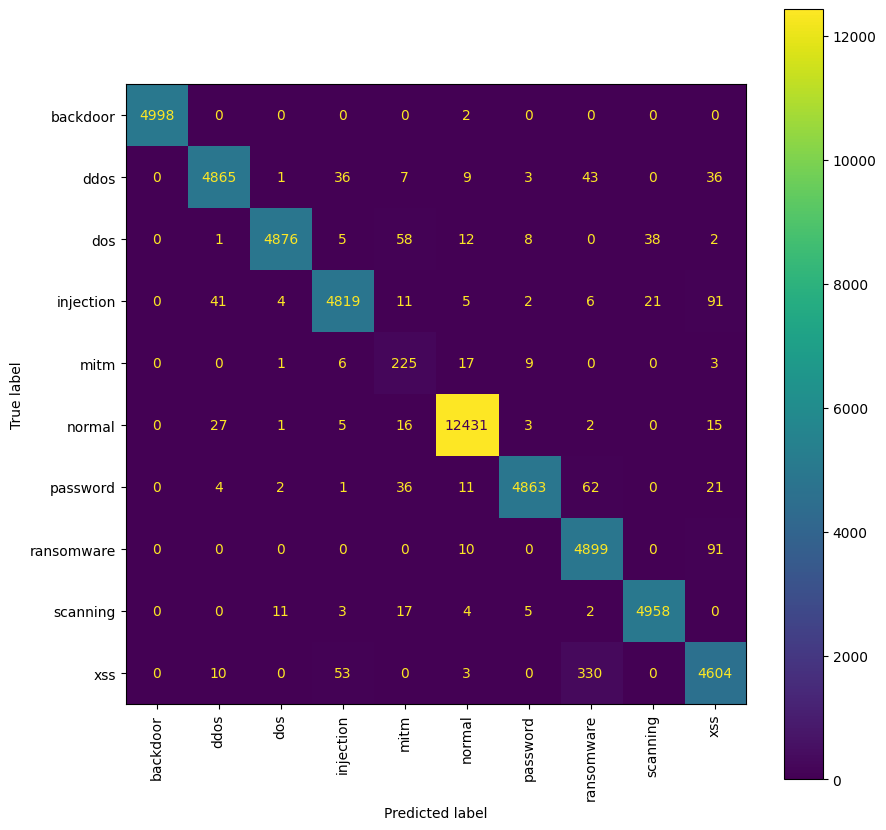

In [37]:
# Hybrid Model
# Defining Hybrid Ensemble Learning Model

from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
# from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

estimators = []

#Defining Decision Tree Classifiers
model1 = DecisionTreeClassifier(criterion='gini',
                                min_samples_split=55,
                               random_state=0)
estimators.append(('cart1', model1))
model2 = DecisionTreeClassifier(criterion='entropy',
                                min_samples_split=50,
                                random_state=0)
estimators.append(('cart3', model2))


#Defining K-NN classifiers
model3 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p = 2)
estimators.append(('knn1', model3))

model4 = XGBClassifier()
estimators.append(('xgboost', model4))

model5 = RandomForestClassifier(n_estimators=100,
                                criterion="entropy",
                                min_samples_split=40,
                                random_state=0)
estimators.append(('rf1', model5))

model6 = RandomForestClassifier(n_estimators=200,
                                criterion="entropy",
                                min_samples_split=35,
                                random_state=0)
estimators.append(('rf2', model6))

# Defining the ensemble model
ensemble = VotingClassifier(estimators,
                            voting='hard',
                            weights=[1, 1, 1, 1, 1.1, 1.1])

ensemble.fit(scaled_X_train, y_train)
y_pred_hybrid = ensemble.predict(scaled_X_val)

print(evaluate_model(y_val, y_pred_hybrid))
print(classification_report(y_val, y_pred_hybrid))
plot_confusion_matrix(y_val, y_pred_hybrid, label)

Visualize Results

In [38]:
# Create empty list for accuracy, precision, recall and f1-score of each ml algorithm
accuracy_score_tf = [0.767450, 0.976315, 0.64376, 0.980575, 0.982119, 0.973530, 0.795343, 0.981737]
precision_score_tf = [0.57739, 0.91399, 0.24908, 0.92927, 0.94231, 0.91748, 0.595091, 0.94106]
recall_score_tf = [0.43996, 0.92330, 0.14148, 0.93199, 0.94332, 0.91353, 0.56224, 0.94330]
f1_score_tf = [0.39360, 0.91813, 0.05164, 0.93046, 0.94263, 0.91492, 0.524571, 0.94197]

models = ["Logistic Regression", "KNN", "Naive Bayes", "Decision Tree",
          "Random Forest", "XGBoost", "ANN", "Hybrid Model"]

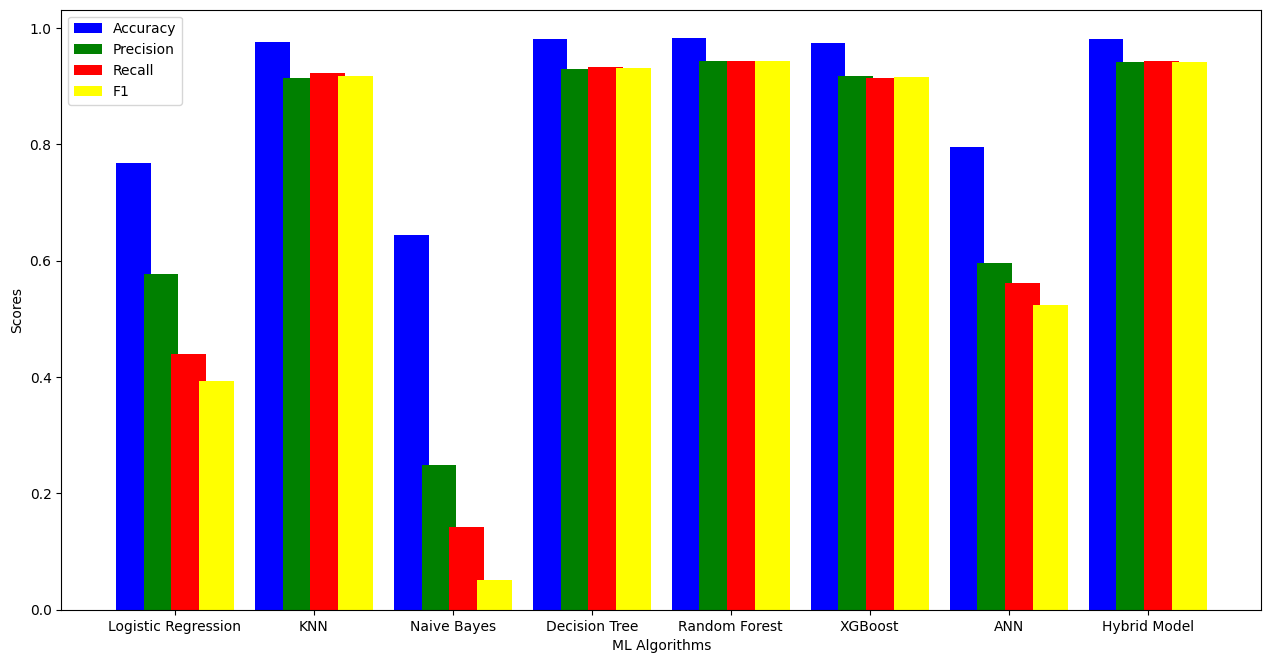

In [39]:
X = np.arange(8)
fig = plt.figure(figsize=(12,6))
ax = fig.add_axes([0,0,1,1])
ax.bar(X + 0.00, accuracy_score_tf, color = 'b', width = 0.25)
ax.bar(X + 0.20, precision_score_tf, color = 'g', width = 0.25)
ax.bar(X + 0.40, recall_score_tf, color = 'r', width = 0.25)
ax.bar(X + 0.60, f1_score_tf, color = 'yellow', width = 0.25)
plt.xticks(X+0.30, models)
plt.xlabel("ML Algorithms")
plt.ylabel("Scores")
plt.legend(["Accuracy", "Precision", "Recall", "F1"])

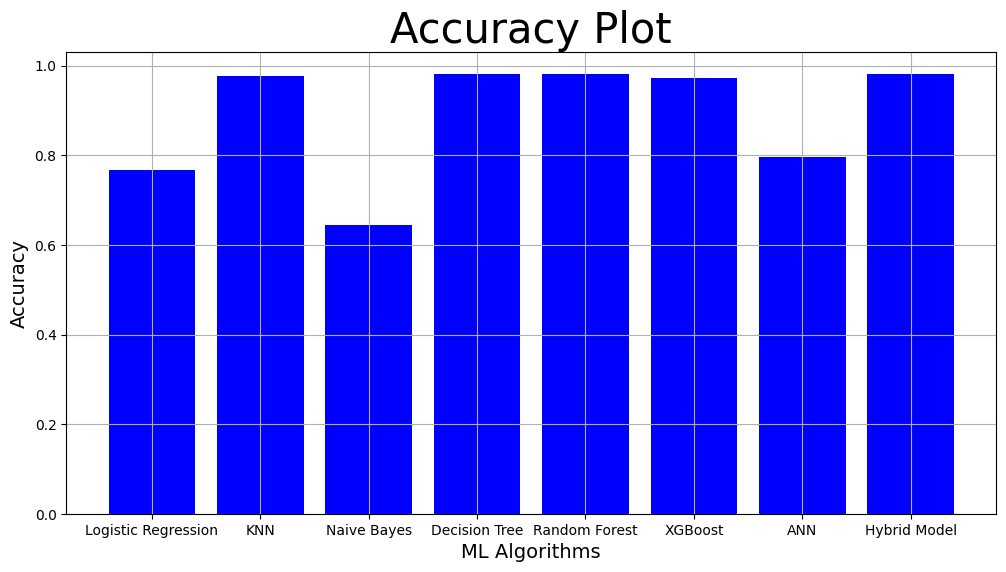

In [40]:
# Accuracy Plot
plt.figure(figsize=(12,6))
colour = ['green', 'blue', 'orange', 'violet', 'brown', 'red', 'magenta', 'yellow']

models = ["Logistic Regression", "KNN", "Naive Bayes", "Decision Tree",
          "Random Forest", "XGBoost", "ANN", "Hybrid Model"]
ax = plt.gca()

plt.bar(models, accuracy_score_tf, color='b')
plt.title('Accuracy Plot', fontsize=30)
plt.xlabel('ML Algorithms', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.grid(True)
plt.show()

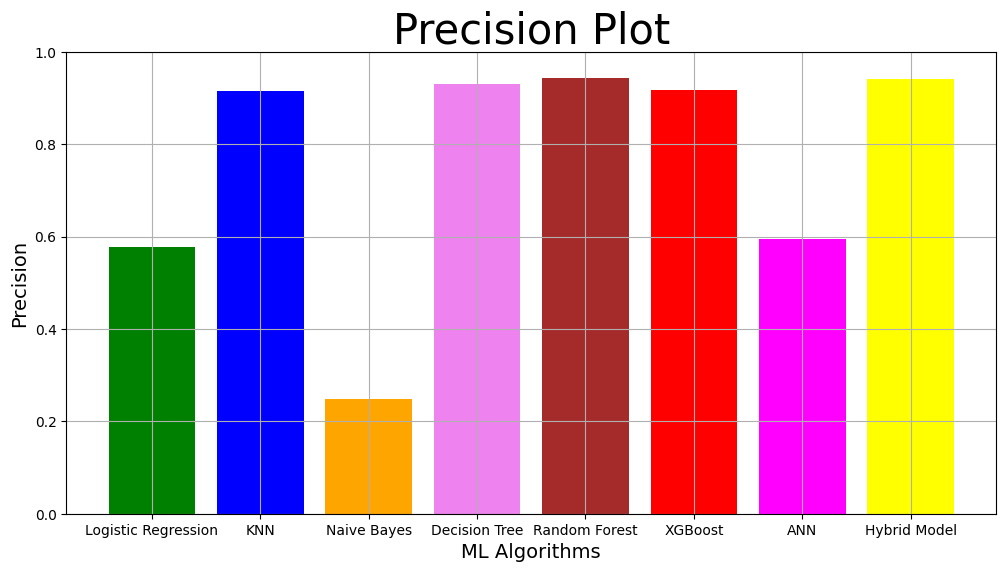

In [41]:
# Precision Plot
plt.figure(figsize=(12,6))

ax = plt.gca()
plt.ylim(0, 1)
plt.bar(models, precision_score_tf, color=colour)
plt.title('Precision Plot', fontsize=30)
plt.xlabel('ML Algorithms', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.grid(True)
plt.show()

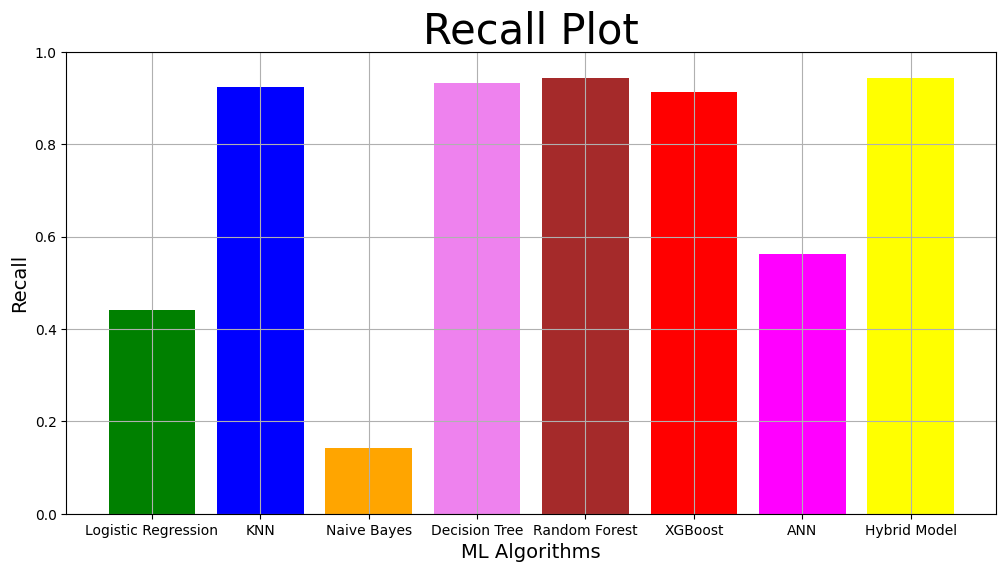

In [42]:
# Recall Plot
plt.figure(figsize=(12,6))

ax = plt.gca()
plt.ylim(0, 1)
plt.bar(models, recall_score_tf, color=colour)
plt.title('Recall Plot', fontsize=30)
plt.xlabel('ML Algorithms', fontsize=14)
plt.ylabel('Recall', fontsize=14)
plt.grid(True)
plt.show()

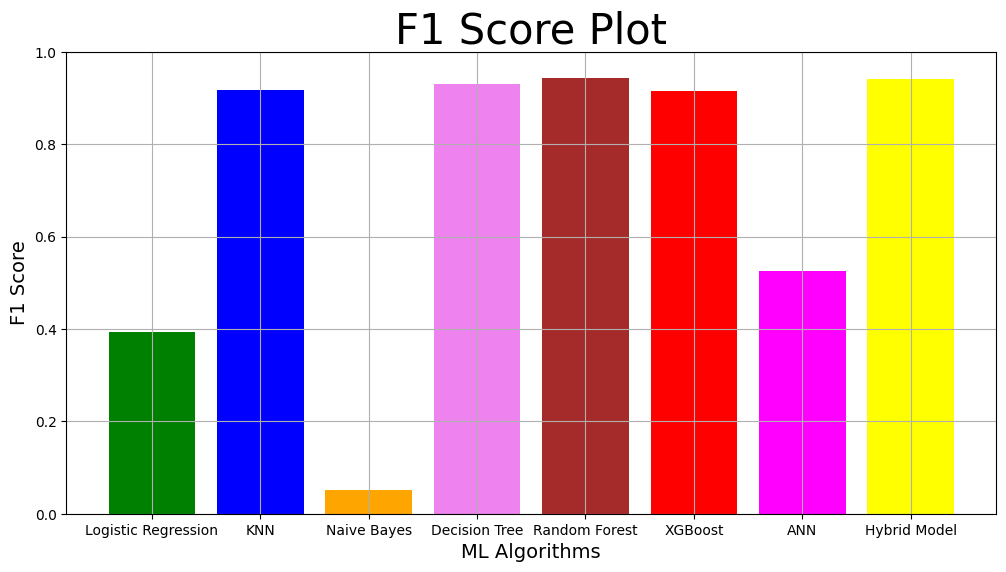

In [43]:
# F1-Score Plot
plt.figure(figsize=(12,6))

ax = plt.gca()
plt.ylim(0, 1)
plt.bar(models, f1_score_tf, color=colour)
plt.title('F1 Score Plot', fontsize=30)
plt.xlabel('ML Algorithms', fontsize=14)
plt.ylabel('F1 Score', fontsize=14)
plt.grid(True)
plt.show()